<a href="https://colab.research.google.com/github/aryan30-tp/Deep-learning/blob/main/CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

keras.utils.set_random_seed(42)

In [2]:
(X_train,y_train),(X_test,y_test)=keras.datasets.fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
print(X_train.shape,y_train.shape)
print(X_test.shape,y_test.shape)

(60000, 28, 28) (60000,)
(10000, 28, 28) (10000,)


In [4]:
labels=["T-shirt/top",
        "Trouser",
        "Pullover",
        "Dress",
        "Coat",
        "Sandal",
        "Shirt",
        "Sneaker",
        "Bag",
        "Ankle Boot"]

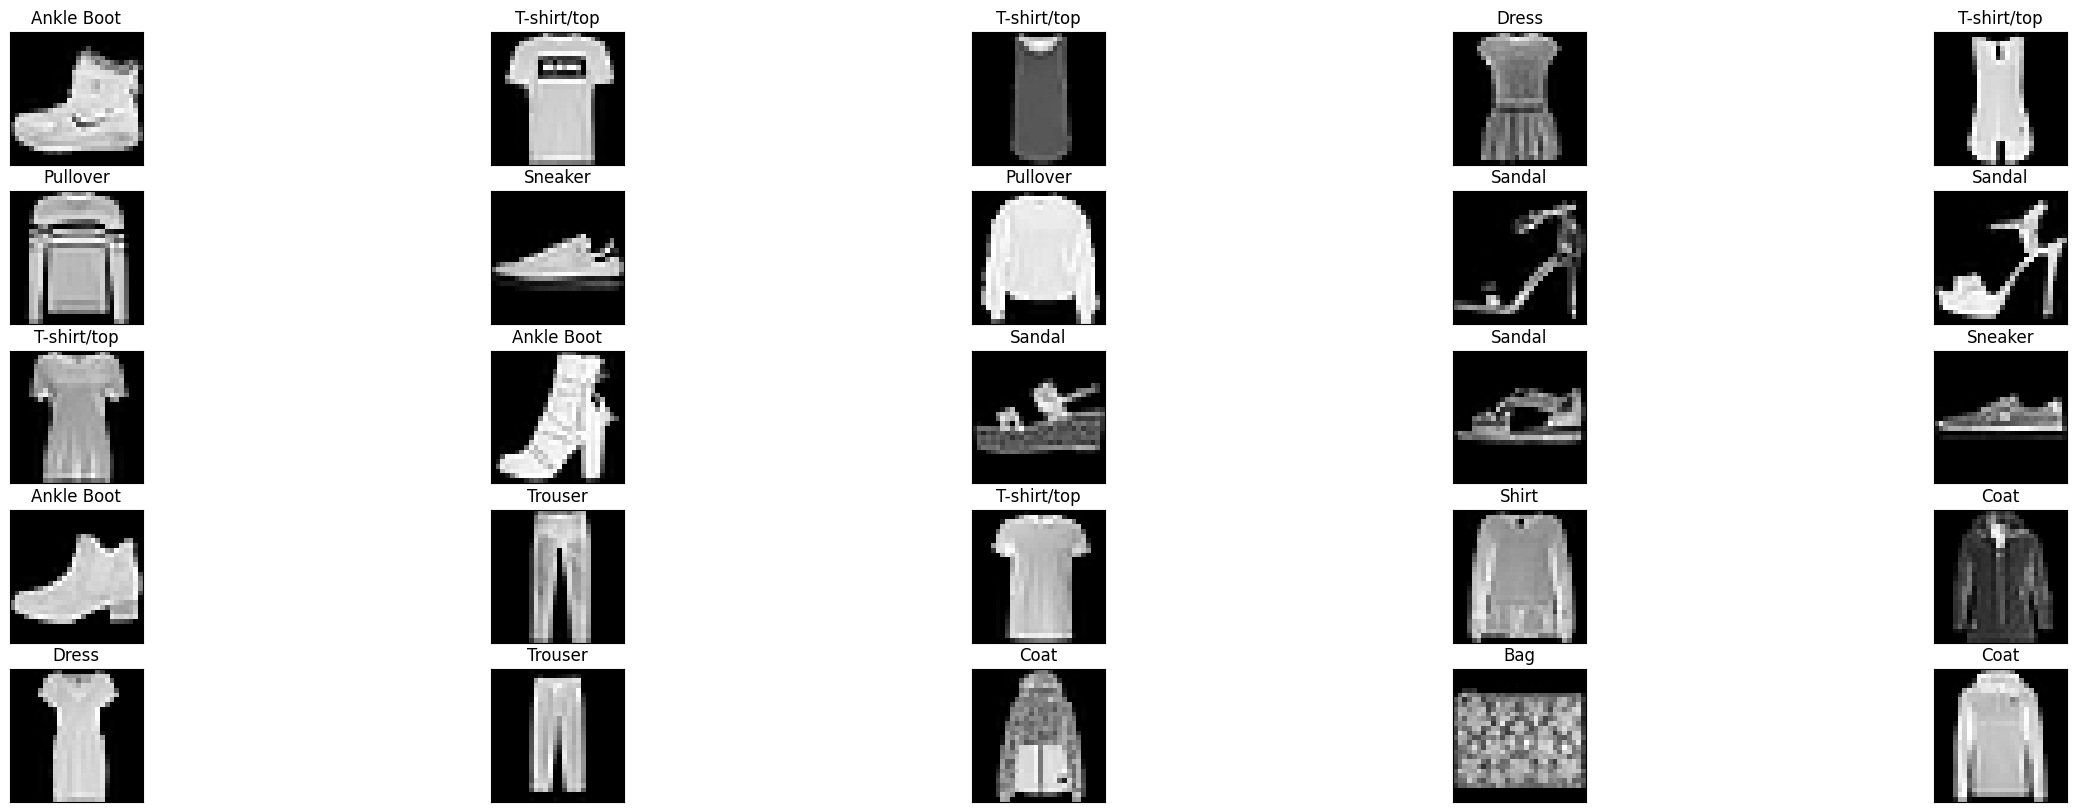

In [6]:
fig, ax= plt.subplots(5, 5, figsize=(30,10))
for i in range(25):
  axc=ax[i//5, i%5]
  axc.imshow(X_train[i], cmap="gray")
  axc.set_title(f"{labels[y_train[i]]}")
  axc.set_xticks([])
  axc.set_yticks([])

In [7]:
X_train=X_train/255.0
X_test=X_test/255.0

In [8]:
X_train.shape

(60000, 28, 28)

In [9]:
X_train=np.expand_dims(X_train,-1)
X_test=np.expand_dims(X_test,-1)

In [10]:
X_train.shape

(60000, 28, 28, 1)

**CNN**

In [36]:
input=keras.Input(shape=X_train.shape[1:])
#1st convolutional block
x=keras.layers.Conv2D(32,kernel_size=(2,2), activation='relu',name="Conv_1")(input)
x=keras.layers.MaxPool2D()(x)
#2nd convolutional block
x=keras.layers.Conv2D(32,kernel_size=(2,2),activation='relu',name="Conv_2")(x)
x=keras.layers.MaxPool2D()(x)
x=keras.layers.Flatten()(x)
x=keras.layers.Dense(256,activation='relu',name='Hidden_layer_1')(x)
output=keras.layers.Dense(10,activation="softmax",name="output")(x)
model=keras.Model(input,output)

In [37]:
model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv_1 (Conv2D)                 │ (None, 27, 27, 32)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv_2 (Conv2D)                 │ (None, 12, 12, 32)     │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 6, 6, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_layer_1 (Dense)          │ (None, 256)            │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 302,026 (1.15 MB)

 Trainable params: 302,026 (1.15 MB)

 Non-trainable params: 0 (0.00 B)

In [38]:
model.compile(loss="sparse_categorical_crossentropy",optimizer="adam",metrics=["accuracy"])

In [40]:
history=model.fit(X_train,y_train,epochs=10,batch_size=64,validation_split=0.2)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 19s 25ms/step - accuracy: 0.8710 - loss: 0.3578 - val_accuracy: 0.8789 - val_loss: 0.3370
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 22s 28ms/step - accuracy: 0.8906 - loss: 0.3004 - val_accuracy: 0.8899 - val_loss: 0.2979
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 22s 29ms/step - accuracy: 0.9028 - loss: 0.2664 - val_accuracy: 0.8957 - val_loss: 0.2825
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 17s 23ms/step - accuracy: 0.9121 - loss: 0.2407 - val_accuracy: 0.9031 - val_loss: 0.2670
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 18s 24ms/step - accuracy: 0.9207 - loss: 0.2188 - val_accuracy: 0.9051 - val_loss: 0.2618
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 17s 23ms/step - accuracy: 0.9285 - loss: 0.1986 - val_accuracy: 0.9071 - val_loss: 0.2582
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 18s 24ms/step - accuracy: 0.9361 - loss: 0.1781 - val_accuracy: 0.9091 - val_loss: 0.2592
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 18s 23ms/step - accuracy: 0.9431 - loss: 0.1594 - 

In [41]:
model.evaluate(X_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8999 - loss: 0.3256


[0.32563841342926025, 0.8999000191688538]

### Predict on a Sample Image

Let's pick a random image from the test set, display it, and see what the model predicts.

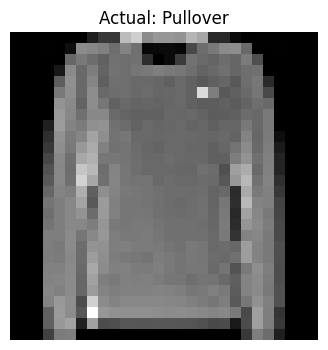

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Predicted: Pullover (Confidence: 99.89%)


In [45]:
import random
import matplotlib.pyplot as plt

# Select a random index from the test set
random_index = random.randint(0, len(X_test) - 1)

# Get the image and its true label
sample_image = X_test[random_index]
sample_label = y_test[random_index]

# Display the image
plt.figure(figsize=(4, 4))
plt.imshow(sample_image.reshape(28, 28), cmap='gray')
plt.title(f"Actual: {labels[sample_label]}")
plt.axis('off')
plt.show()

# Make a prediction
# The model expects a batch of images, so we add an extra dimension
predicted_probabilities = model.predict(np.expand_dims(sample_image, axis=0))
predicted_class = np.argmax(predicted_probabilities)

print(f"Predicted: {labels[predicted_class]} (Confidence: {np.max(predicted_probabilities)*100:.2f}%)")

### Classify an Uploaded Image

To classify an image from your computer, please run the following code cell. It will prompt you to choose an image file. Once uploaded, the image will be preprocessed and your model will make a prediction.

In [49]:
from google.colab import files
from PIL import Image
import io

# Upload an image file
uploaded = files.upload()

for fn in uploaded.keys():
  print(f'User uploaded file "{fn}"')
  # Read the image file
  img = Image.open(io.BytesIO(uploaded[fn]))

  # Preprocess the image for the model
  # Convert to grayscale if not already
  if img.mode != 'L':
      img = img.convert('L')

  # Resize to 28x28 pixels
  img = img.resize((28, 28))

  # Convert to numpy array and normalize
  uploaded_image_array = np.array(img, dtype=np.float32) / 255.0

  # Add batch and channel dimensions (1, 28, 28, 1)
  uploaded_image_array = np.expand_dims(uploaded_image_array, axis=0)
  uploaded_image_array = np.expand_dims(uploaded_image_array, axis=-1)

  # Display the uploaded image (optional, for verification)
  plt.figure(figsize=(4, 4))
  plt.imshow(img, cmap='gray')
  plt.title("Uploaded Image")
  plt.axis('off')
  plt.show()

  # Make a prediction
  predicted_probabilities_uploaded = model.predict(uploaded_image_array)
  predicted_class_uploaded = np.argmax(predicted_probabilities_uploaded)

  print(f"Predicted: {labels[predicted_class_uploaded]} (Confidence: {np.max(predicted_probabilities_uploaded)*100:.2f}%)")
  break # Process only the first uploaded file